# AIoT Project

In [70]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]

In [8]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 25 keys in the collection


## Load data

In [76]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({}, {"data": True, "gesture_id": True}))
print(f'Found {len(results)} keys in the collection')

Found 25 keys in the collection


In [ ]:
all_chunks = pd.DataFrame(results)
# print(all_chunks)

gestures = []
for gesture_chunks in all_chunks[['gesture_id', 'data']].itertuples():
    print(gesture_chunks)
    print(type(gesture_chunks))
    label = gesture_chunks.gesture_id
    current_data = gesture_chunks.data
    
    chunks = []
    for chunk in current_data:
        print(chunk)
        # df = pd.DataFrame(chunk)
        dp = df.drop(df.tail(200).index, inplace=True)
        dp = df.drop(df.head(200).index, inplace=True)
        chunks.append((label, df))

    joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
    gestures.append(joined_gesture)

    # print(len(chunks[0][1]))
    # print(chunks[0][1].head())

    print(len(joined_gesture))
    print(joined_gesture.head())
    
    
print(len(gestures))
print(gestures[0].head())




Pandas(Index=0, gesture_id='scroll-down-index', data={'acc_x': [0.049, 0.048, 0.033, 0.012, -0.008, -0.009, -0.004, -0.01, -0.019, -0.015, -0.015, -0.027, -0.032, -0.032, -0.042, -0.053, -0.069, -0.071, -0.062, -0.051, -0.045, -0.047, -0.036, -0.019, -0.02, -0.009, 0.004, -0.001, -0.021, -0.036, -0.045, -0.045, -0.046, -0.044, -0.035, -0.013, 0.004, -0.011, -0.023, -0.033, -0.043, -0.038, -0.039, -0.037, -0.036, -0.026, -0.022, -0.033, -0.038, -0.04, -0.035, -0.016, -0.017, -0.023, -0.021, -0.004, -0.001, -0.01, -0.016, -0.021, -0.019, -0.015, -0.017, -0.018, -0.012, -0.015, -0.023, -0.028, -0.031, -0.028, -0.021, -0.019, -0.02, -0.024, -0.033, -0.035, -0.041, -0.038, -0.032, -0.034, -0.03, -0.021, -0.022, -0.02, -0.021, -0.023, -0.017, -0.014, -0.015, -0.017, -0.016, -0.018, -0.015, -0.017, -0.009, -0.009, -0.014, -0.023, -0.029, -0.022, -0.027, -0.032, -0.032, -0.029, -0.021, -0.021, -0.026, -0.03, -0.031, -0.032, -0.03, -0.025, -0.023, -0.025, -0.021, -0.01, -0.015, -0.017, -0.014, 

ValueError: DataFrame constructor not properly called!

## Explore the nature of the data

In [72]:
df = joined_gesture
print(df.value_counts)

<bound method DataFrame.value_counts of        acc_x  acc_y  acc_z  gyr_x   gyr_y  gyr_z
0     -0.086 -0.269  0.960  0.122   2.317 -0.671
1     -0.093 -0.268  0.964  0.671   4.085 -1.768
2     -0.097 -0.268  0.962  1.707   6.585 -3.232
3     -0.089 -0.266  0.962  2.683   9.939 -5.122
4     -0.095 -0.268  0.958  3.963  12.866 -7.378
...      ...    ...    ...    ...     ...    ...
33552 -0.160 -0.445  0.876  2.195  -2.500  0.732
33553 -0.164 -0.447  0.870  2.805  -2.683  0.427
33554 -0.157 -0.447  0.869  3.293  -2.744  0.000
33555 -0.148 -0.446  0.872  3.902  -1.707 -0.732
33556 -0.152 -0.448  0.872  5.183   0.549 -2.012

[33557 rows x 6 columns]>


In [62]:
# throw away acc to see whats up
# df = df.drop(columns=['gyr_x', 'gyr_y', 'gyr_z'])
df = df.drop(columns=['acc_x', 'acc_y', 'acc_z'])

Number of filtered instances in the list: 32


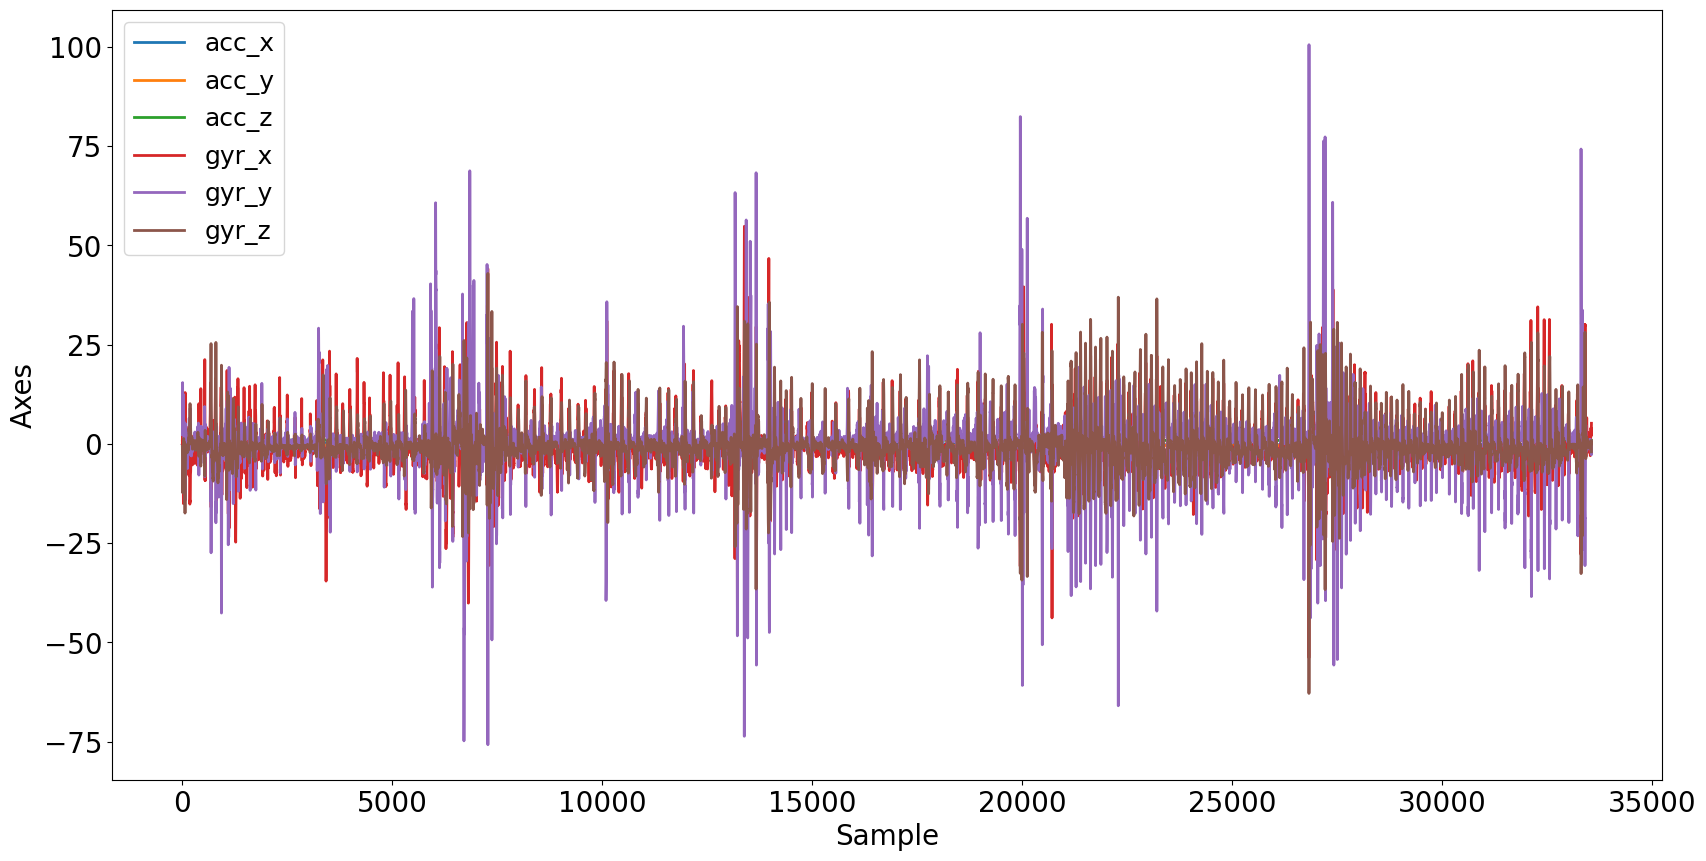

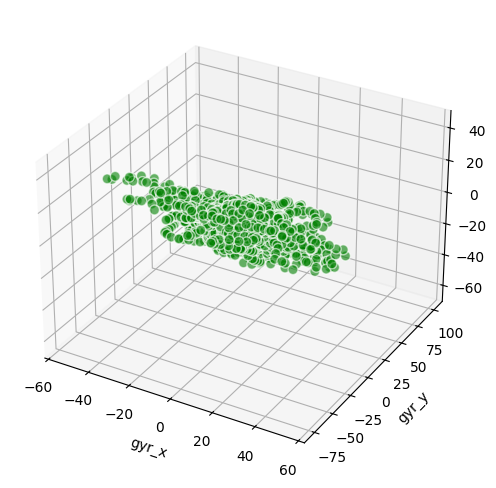

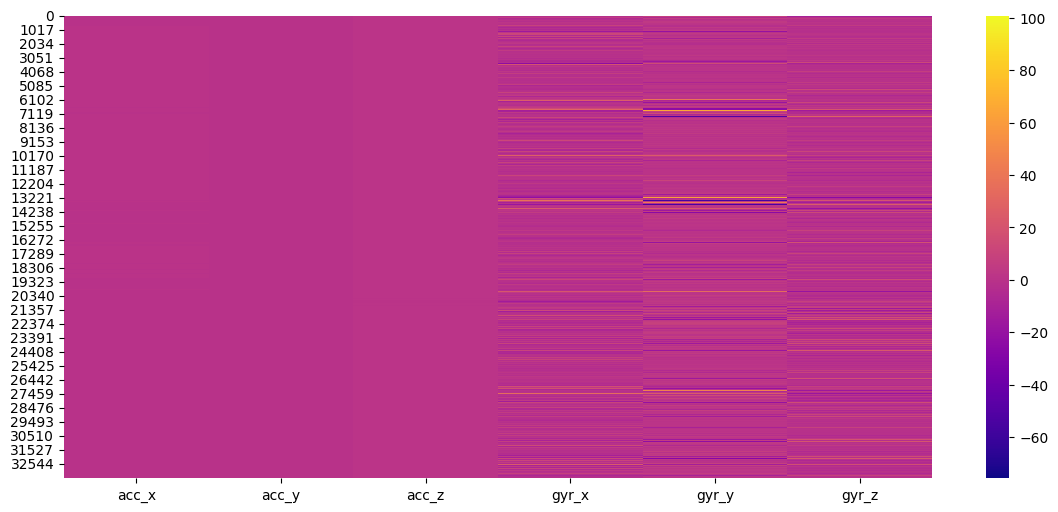

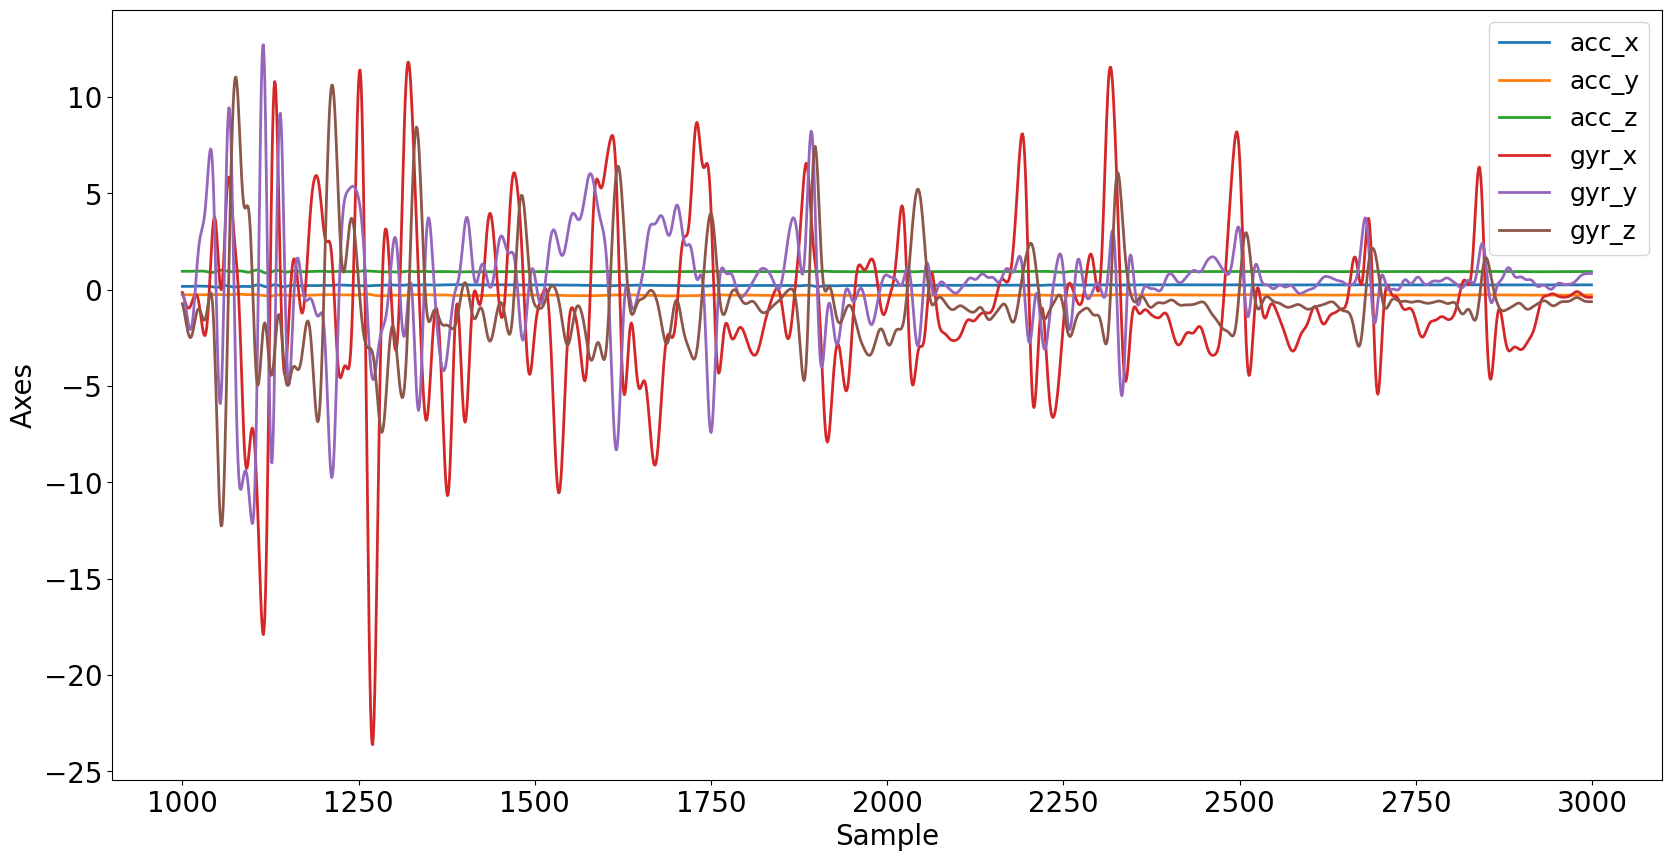

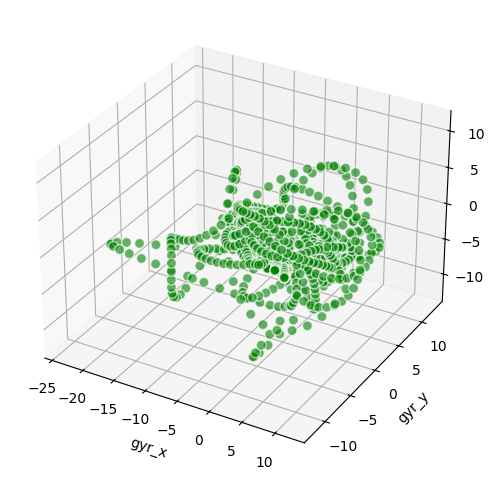

In [73]:
plot_instance_time_domain(df)
plot_instance_3d(df, axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(df, axes_list=['acc_x', 'acc_y', 'acc_z'])
plot_heatmap(df)

# slice data into windows
clips = sliding_window_pd(df, ws=2000, overlap=1000, print_stats=False)
fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
plot_instance_time_domain(fclips[1])
plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])


Print Window: 1
Number of samples: 2000
Print Window: 2
Number of samples: 2000
Print Window: 3
Number of samples: 2000
Print Window: 4
Number of samples: 2000
List number of window instances: 4
Number of filtered instances in the list: 4


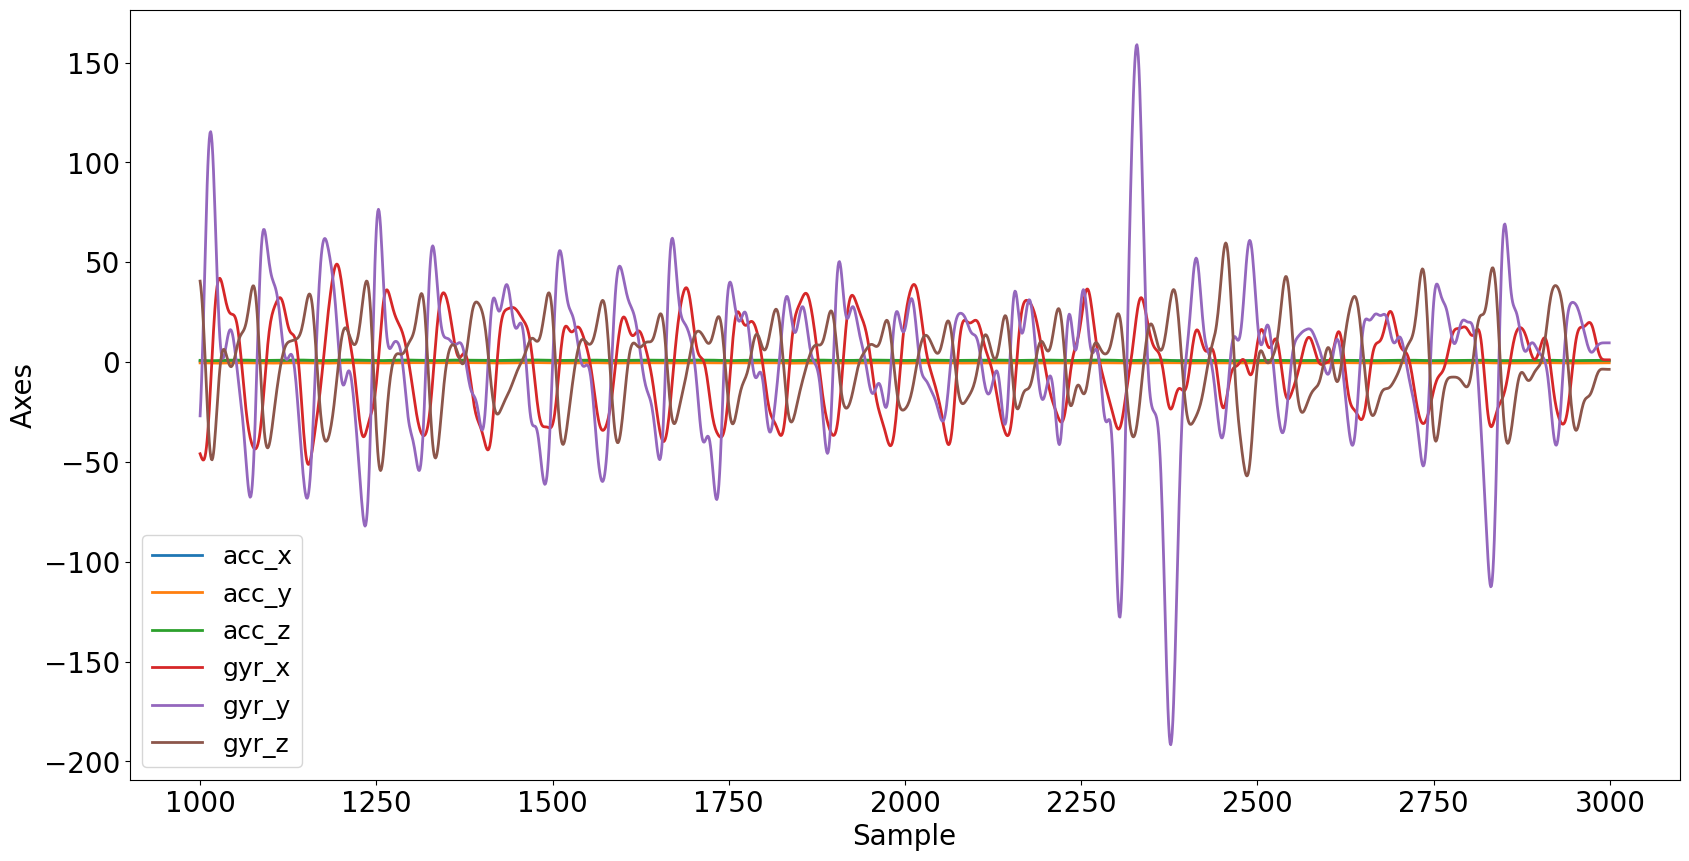

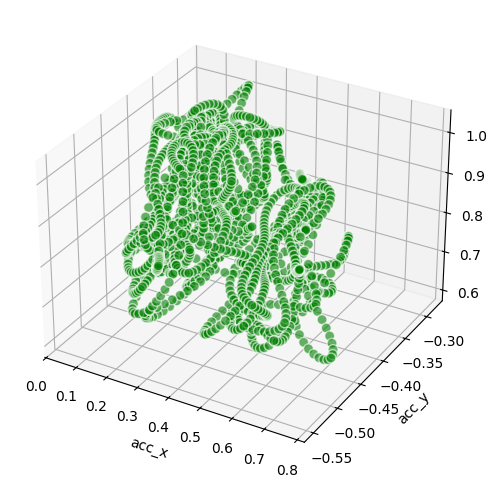

## Data Processing

## Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Classifier - Statistical Learning

### Apply simple classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Evaluate simple classifier

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier